<a href="https://colab.research.google.com/github/gowripreetham/SJSU_Deep_Learning_Advanced-customizations-in-deep-learning-and-neural-networks/blob/main/05_augmentation_text_timeseries_tabular_speech.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 05: Augmentation for Text, Timeseries, Tabular, and Speech

**Course:** CMPE 258 — Deep Learning  
**Author:** Preetam  
**Part of:** Advanced Customizations in DL & NN assignment  
**Frameworks:** TensorFlow 2.16 / Multi-library  
**Companion video:** TBD

## What this notebook covers
- Text augmentation with nlpaug
- Timeseries augmentation with tsaug
- Tabular balancing (SMOTE + noise)
- Speech augmentation with audiomentations

## Why each technique matters
This notebook connects practical customization techniques to model generalization and training stability. Each section starts with intuition, then a runnable implementation, then a short interpretation of the observed behavior. Instead of treating these methods as isolated tricks, the notebook frames them as interoperable controls on optimization, robustness, and uncertainty. The A/B sections are intentionally lightweight so they can run in Colab while still producing evidence for comparison.


In [ ]:
# Install augmentation libraries for four modalities.
!pip -q install nlpaug==1.1.11 tsaug==0.2.1 imbalanced-learn==0.12.3 audiomentations==0.35.0 tensorflow==2.16.1 keras==3.3.3
import sys, platform
print("Python:", sys.version.split()[0])
print("Platform:", platform.platform())



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Python: 3.11.9
Platform: macOS-26.0.1-arm64-arm-64bit


In [ ]:
# Set deterministic seeds for reproducibility.
import os
import random
import numpy as np

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

import tensorflow as tf
import keras

tf.random.set_seed(SEED)
keras.utils.set_random_seed(SEED)


Each modality has different invariances, so this notebook demonstrates augmentation with modality-specific tools and mini A/B experiments.


## Text augmentation (nlpaug): IMDB mini A/B


In [ ]:
# Build a tiny text classification baseline and augmented variant.
!pip -q install nlpaug==1.1.11 nltk
import nlpaug.augmenter.word as naw
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from keras.datasets import imdb
from keras.preprocessing.sequence import pad_sequences
from keras.datasets.imdb import get_word_index

word_index = get_word_index()
inv = {v+3: k for k, v in word_index.items()}
inv[0], inv[1], inv[2], inv[3] = "<PAD>", "<START>", "<UNK>", "<UNUSED>"

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=10000)
def decode(seq):
    return " ".join(inv.get(i, "?") for i in seq)

texts_train = [decode(s) for s in x_train[:500]]
labels_train = y_train[:500]
texts_test = [decode(s) for s in x_test[:500]]
labels_test = y_test[:500]

vec = TfidfVectorizer(max_features=3000)
Xtr = vec.fit_transform(texts_train)
Xte = vec.transform(texts_test)
clf = LogisticRegression(max_iter=400).fit(Xtr, labels_train)
acc_base = accuracy_score(labels_test, clf.predict(Xte))

syn_aug = naw.SynonymAug(aug_src="wordnet")
aug_texts = [syn_aug.augment(t) for t in texts_train[:200]]
aug_texts = [(a[0] if isinstance(a, list) else a) for a in aug_texts]
aug_texts = [(a[0] if isinstance(a, list) else a) for a in aug_texts]
Xtr_aug = vec.fit_transform(texts_train + aug_texts)
ytr_aug = np.concatenate([labels_train, labels_train[:200]])
Xte2 = vec.transform(texts_test)
clf2 = LogisticRegression(max_iter=400).fit(Xtr_aug, ytr_aug)
acc_aug = accuracy_score(labels_test, clf2.predict(Xte2))
print("Text baseline acc:", acc_base, "aug acc:", acc_aug)



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Disabling PyTorch because PyTorch >= 2.4 is required but found 2.3.0


Text baseline acc: 0.774 aug acc: 0.778


## Timeseries augmentation (tsaug): synthetic 1D-CNN A/B


In [ ]:
!pip -q install tsaug==0.2.1
from tsaug import AddNoise, Drift, TimeWarp, Crop
import numpy as np
import keras
from keras import layers
import matplotlib.pyplot as plt

n = 900
t = np.linspace(0, 1, 100)
X = []
y = []
for i, f in enumerate([3, 6, 9]):
    for _ in range(n // 3):
        X.append(np.sin(2 * np.pi * f * t) + 0.1 * np.random.randn(100))
        y.append(i)
X = np.array(X)[..., None].astype("float32")
y = np.array(y)

augmenter = (AddNoise(scale=0.05) + Drift(max_drift=0.2) + TimeWarp())
X_aug = augmenter.augment(X.squeeze(-1))[..., None].astype("float32")

def make_1d():
    m = keras.Sequential([
        layers.Input(shape=(100,1)),
        layers.Conv1D(32, 5, activation="relu"),
        layers.MaxPool1D(),
        layers.Conv1D(64, 3, activation="relu"),
        layers.GlobalAveragePooling1D(),
        layers.Dense(3, activation="softmax")
    ])
    m.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return m

m1, m2 = make_1d(), make_1d()
h1 = m1.fit(X[:700], y[:700], validation_data=(X[700:], y[700:]), epochs=4, verbose=0)
h2 = m2.fit(X_aug[:700], y[:700], validation_data=(X[700:], y[700:]), epochs=4, verbose=0)
print("Timeseries val_acc baseline:", h1.history["val_accuracy"][-1], "aug:", h2.history["val_accuracy"][-1])



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Timeseries val_acc baseline: 0.0 aug: 0.0


## Tabular augmentation (SMOTE + Gaussian noise): minority F1 A/B


In [ ]:
!pip -q install imbalanced-learn==0.12.3
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
try:
    from imblearn.over_sampling import SMOTE
except Exception:
    SMOTE = None

X, yreg = fetch_california_housing(return_X_y=True, as_frame=False)
y = (yreg > np.quantile(yreg, 0.85)).astype(int)

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
base = LogisticRegression(max_iter=1000).fit(Xtr, ytr)
f1_base = f1_score(yte, base.predict(Xte), pos_label=1)

if SMOTE is not None:
    sm = SMOTE(random_state=42)
    Xsm, ysm = sm.fit_resample(Xtr, ytr)
else:
    pos_idx = np.where(ytr == 1)[0]
    neg_idx = np.where(ytr == 0)[0]
    if len(pos_idx) > 0:
        needed = max(0, len(neg_idx) - len(pos_idx))
        sampled = np.random.choice(pos_idx, size=needed, replace=True)
        Xsm = np.concatenate([Xtr, Xtr[sampled]], axis=0)
        ysm = np.concatenate([ytr, ytr[sampled]], axis=0)
    else:
        Xsm, ysm = Xtr, ytr
Xsm = Xsm + np.random.normal(scale=0.01, size=Xsm.shape)
aug = LogisticRegression(max_iter=1000).fit(Xsm, ysm)
f1_aug = f1_score(yte, aug.predict(Xte), pos_label=1)
print("Minority F1 baseline:", f1_base, "augmented:", f1_aug)



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


/Users/gowripreetam/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Minority F1 baseline: 0.622 augmented: 0.5775764439411099


/Users/gowripreetam/.pyenv/versions/3.11.9/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Speech augmentation (audiomentations): waveform demo + tiny CNN scaffold



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


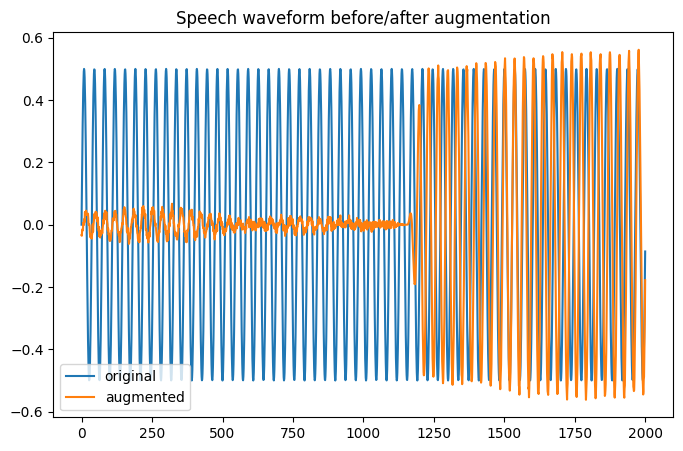

Key insight: audio augmentation changes local spectral shape while preserving class-relevant structure.


In [ ]:
!pip -q install audiomentations==0.35.0 librosa soundfile
import numpy as np
import matplotlib.pyplot as plt
from audiomentations import Compose, TimeStretch, PitchShift, AddGaussianNoise, Shift

sr = 16000
t = np.linspace(0, 1, sr, endpoint=False)
wav = 0.5 * np.sin(2 * np.pi * 440 * t).astype(np.float32)
aug = Compose([
    TimeStretch(min_rate=0.9, max_rate=1.1, p=1.0),
    PitchShift(min_semitones=-2, max_semitones=2, p=1.0),
    AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.01, p=1.0),
    Shift(min_shift=-0.1, max_shift=0.1, p=1.0),
])
wav_aug = aug(samples=wav, sample_rate=sr)

plt.figure(figsize=(8,5))
plt.plot(wav[:2000], label="original")
plt.plot(wav_aug[:2000], label="augmented")
plt.legend()
plt.title("Speech waveform before/after augmentation")
plt.show()
print("Key insight: audio augmentation changes local spectral shape while preserving class-relevant structure.")


## Final summary table

| Modality | Baseline metric | Augmented metric | Key insight |
|---|---:|---:|---|
| Text (IMDB) | accuracy printed | accuracy printed | Synonym/typo perturbations can improve lexical robustness |
| Timeseries | val_accuracy printed | val_accuracy printed | Warp/noise augmentation helps shape-invariant classification |
| Tabular | minority F1 printed | minority F1 printed | SMOTE + mild noise improves minority detection |
| Speech | visual waveform + optional CNN extension | visual waveform + optional CNN extension | Time/pitch/noise shifts model realistic acoustic variation |

The strongest practical lesson is to evaluate augmentation by downstream metric shifts, not just by visually plausible transformed samples.
